# Laboratorium 9 — Matplotlib — podstawy wizualizacji danych
**Autor:** Marta Machacka

## Dane startowe

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Dataset tips — restauracja, 244 rachunki
tips = sns.load_dataset('tips')

# Dane sprzedaży TechShop (z W08)
miesiace = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze']
sprzedaz_2024 = [45230, 38920, 52100, 48700, 55200, 62300]
sprzedaz_2023 = [41000, 35000, 48000, 44000, 50000, 58000]

kategorie = ['Komputery', 'Akcesoria', 'Audio', 'Storage']
sprzedaz_kat = [15899.94, 2939.83, 1199.97, 349.93]

print(f"Tips dataset: {tips.shape}")
print(tips.head(3))

Tips dataset: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


## Ćwiczenie 1: Podstawowe typy wykresów — linia, słupki, scatter

Cel: Stworzyć trzy podstawowe typy wykresów i zapisać jako PNG.

### Zadanie 1.1 — Wykres liniowy: trend sprzedaży
Narysuj wykres liniowy trendu sprzedaży miesięcznej za 2024 rok.

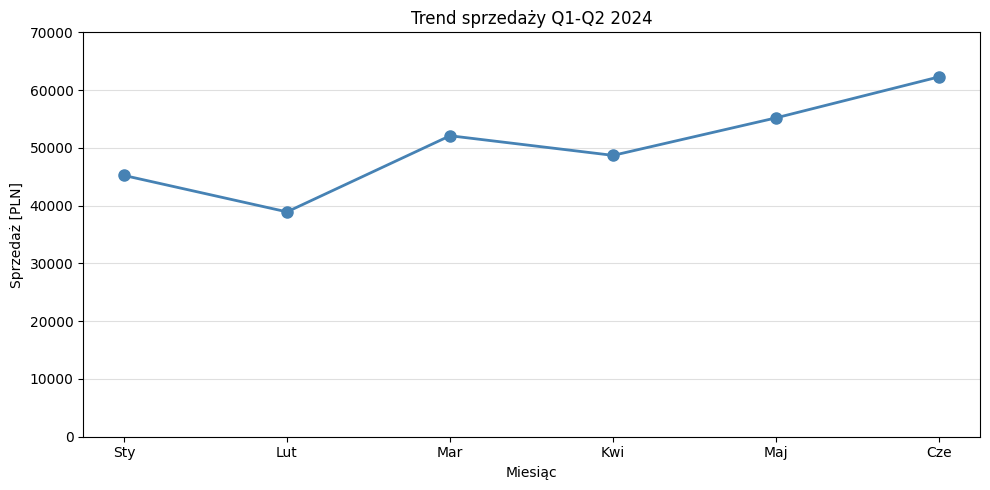

Zapisano: trend_2024.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = 'steelblue',
        linewidth = 2,
        marker = 'o',
        markersize = 8)

ax.set_title('Trend sprzedaży Q1-Q2 2024')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.set_ylim(0, 70000)
ax.grid(axis = 'y', alpha = 0.4)

plt.tight_layout()
plt.savefig('trend_2024.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: trend_2024.png")

### Zadanie 1.2 — Wykres słupkowy: sprzedaż per kategoria
Narysuj wykres słupkowy (pionowy) sprzedaży per kategoria produktów.

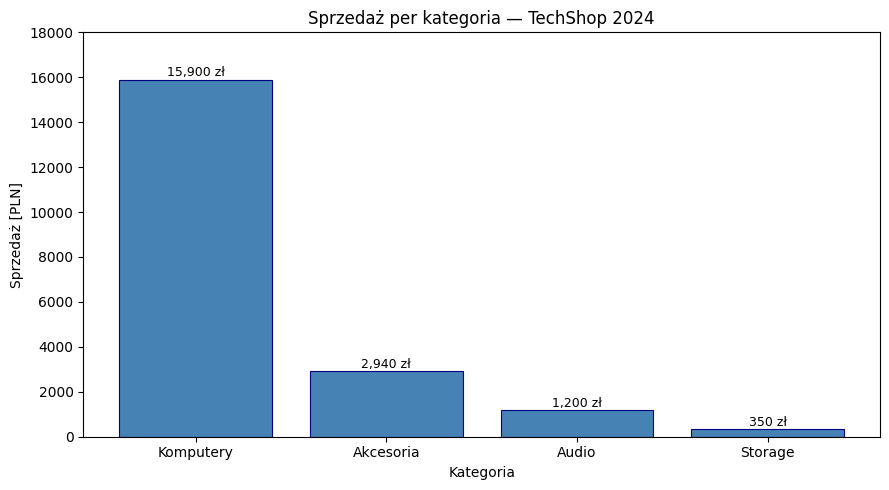

Zapisano: sprzedaz_kategorie.png


In [7]:
fig, ax = plt.subplots(figsize = (9, 5))

slupki = ax.bar(kategorie,
                sprzedaz_kat,
                color = 'steelblue',
                edgecolor = 'navy',
                linewidth = 0.8)

# Dodaj wartości nad słupkami
for slupek, wartosc in zip(slupki, sprzedaz_kat):
    ax.text(
        slupek.get_x() + slupek.get_width() / 2,    # środek słupka w osi X
        slupek.get_height() + 0.7,                  # ile JEDNOSTEK osi Y nad słupkiem? (~0.7% zakresu)
        f'{wartosc:,.0f} zł',                       # format: 11,899 zł
        ha = 'center', va = 'bottom', fontsize = 9             # wyrównanie poziome — środek
    )

ax.set_title('Sprzedaż per kategoria — TechShop 2024')
ax.set_xlabel('Kategoria')
ax.set_ylabel('Sprzedaż [PLN]')
ax.set_ylim(0, 18000)

plt.tight_layout()
plt.savefig('sprzedaz_kategorie.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: sprzedaz_kategorie.png")

### Zadanie 1.3 — Scatter: rachunek vs napiwek (tips dataset)
Narysuj wykres punktowy zależności napiwku od wartości rachunku.

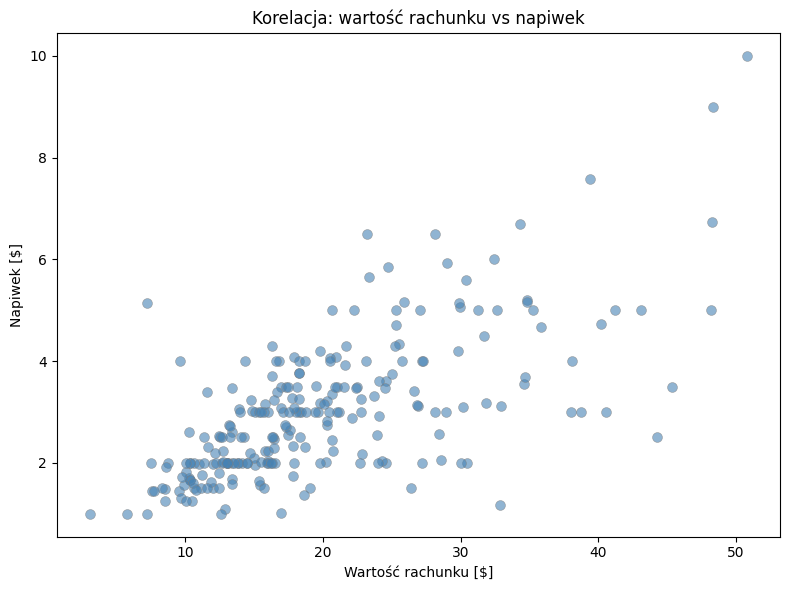

Zapisano: scatter_tips.png


In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

ax.scatter(
    tips['total_bill'], 
    tips['tip'],
    alpha = 0.6,
    color ='steelblue',
    s = 50,   
    edgecolors = 'gray',
    linewidth = 0.5
)

ax.set_title('Korelacja: wartość rachunku vs napiwek')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')

plt.tight_layout()
plt.savefig('scatter_tips.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: scatter_tips.png")

### Wyzwanie dodatkowe
Dodaj do scatter z 1.3 kolorowanie według liczby gości (tips['size']) używając parametru c=tips['size'], cmap='Blues'. Uwaga: żeby colorbar działał, musisz przypisać ax.scatter(...) do zmiennej

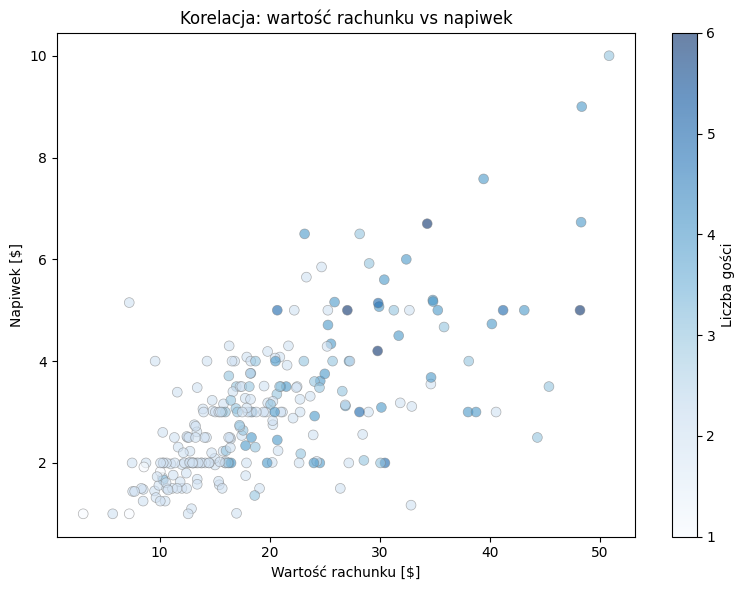

Zapisano: scatter_tips.png


In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

scatter = ax.scatter(
    tips['total_bill'],   
    tips['tip'],
    c = tips['size'],       # kolor zależny od liczby gości
    cmap = 'Blues',         # mapa kolorów
    alpha = 0.6,
    s = 50,
    edgecolors = 'gray',
    linewidth = 0.5
)

plt.colorbar(scatter, ax = ax).set_label('Liczba gości')

ax.set_title('Korelacja: wartość rachunku vs napiwek')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')

plt.tight_layout()
plt.savefig('scatter_tips.png', dpi = 100)
plt.show()
plt.close()

print("Zapisano: scatter_tips.png")


## Ćwiczenie 2: Dostosowywanie — etykiety, kolory, legendy
Cel: Opanować formatowanie wykresów: wiele serii, legenda, styl, kolory.

### Zadanie 2.1 — Porównanie dwóch lat (legenda)
Narysuj wykres liniowy porównujący sprzedaż 2023 i 2024 na jednym wykresie z legendą.

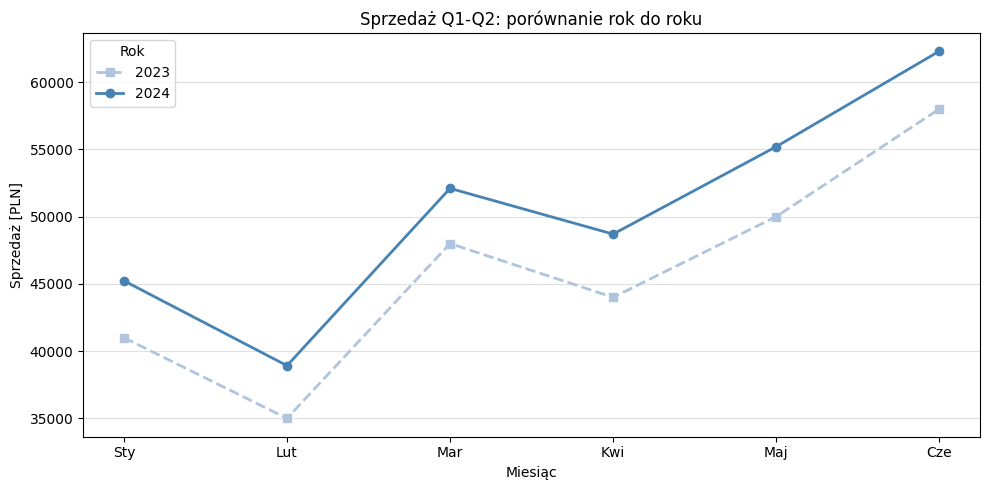

Zapisano: porownanie_lat.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Seria 2023 — linia przerywana
ax.plot(miesiace, sprzedaz_2023,
        label = '2023',
        color = 'lightsteelblue',
        linewidth = 2,
        marker = 's',           # kwadraty
        linestyle = '--')       # przerywana

# Seria 2024 — linia ciągła
ax.plot(miesiace, sprzedaz_2024,
        label = '2024',
        color = 'steelblue',
        linewidth = 2,
        marker = 'o')

ax.set_title('Sprzedaż Q1-Q2: porównanie rok do roku')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend(title = 'Rok', loc = 'upper left')
ax.grid(axis = 'y', alpha = 0.4)

plt.tight_layout()
plt.savefig('porownanie_lat.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: porownanie_lat.png")

### Zadanie 2.2 — Słupki poziome z kolorami (barh)
Narysuj słupki poziome sprzedaży per kategoria. Każdy słupek innym kolorem.

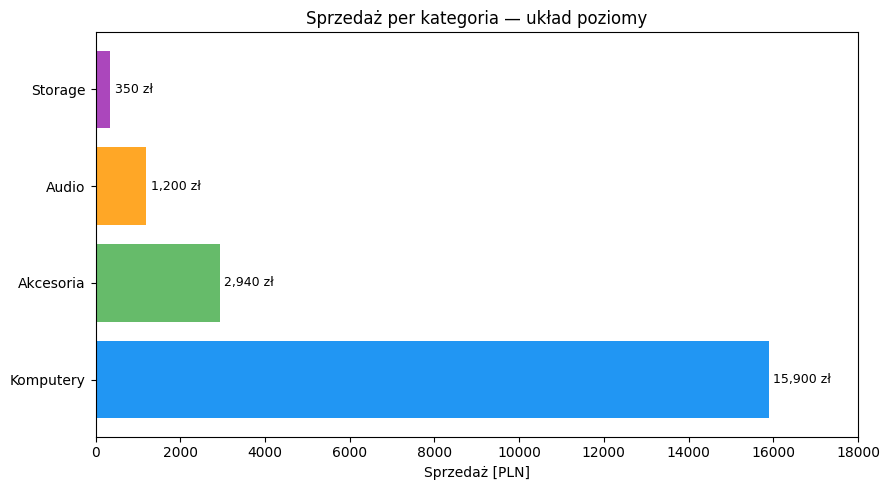

Zapisano: kategorie_poziome.png


In [ ]:
kolory_kat = ['#2196F3', '#66BB6A', '#FFA726', '#AB47BC']

fig, ax = plt.subplots(figsize = (9, 5))

# barh = horizontal bar
ax.barh(kategorie,
        sprzedaz_kat,
        color = kolory_kat)

# Etykiety wartości przy słupkach
for i, (kat, wartosc) in enumerate(zip(kategorie, sprzedaz_kat)):
    ax.text(wartosc + 100, i,
            f'{wartosc:,.0f} zł',
            va='center', fontsize = 9)

ax.set_title('Sprzedaż per kategoria — układ poziomy')
ax.set_xlabel('Sprzedaż [PLN]')
ax.set_xlim(0, 18000)

plt.tight_layout()
plt.savefig('kategorie_poziome.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: kategorie_poziome.png")

### Zadanie 2.3 — Styl wykresów
Zastosuj styl seaborn-v0_8-whitegrid i narysuj wykres liniowy trendu.

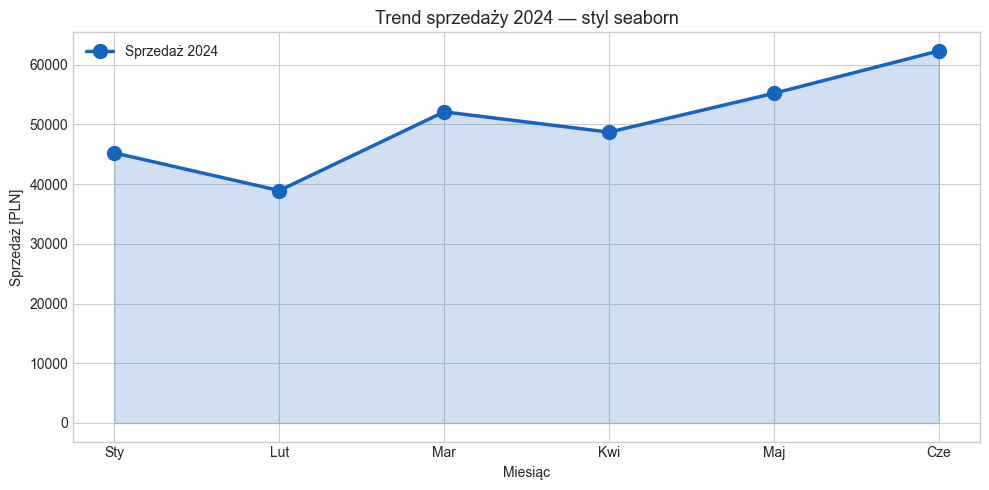

Zapisano: trend_styl.png


In [16]:
# Zastosuj styl
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = '#1565C0',
        linewidth = 2.5,
        marker = 'o',
        markersize = 10,
        label = 'Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
                alpha = 0.2,                # przezroczystość 0-1; subtelny efekt = 0.1-0.2
                color = '#1565C0')                # ten sam kolor co linia powyżej dla spójności

ax.set_title('Trend sprzedaży 2024 — styl seaborn', fontsize = 13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()

plt.tight_layout()
plt.savefig('trend_styl.png', dpi = 100)
plt.show()
plt.close()

# Przywróć domyślny styl
plt.style.use('default')
print("Zapisano: trend_styl.png")

### Wyzwanie dodatkowe
Pobaw się parametrami plt.style.use(). Dostępne style: 'ggplot', 'bmh', 'dark_background', 'fivethirtyeight'. Narysuj ten sam wykres w każdym stylu i porównaj.

- ggplot

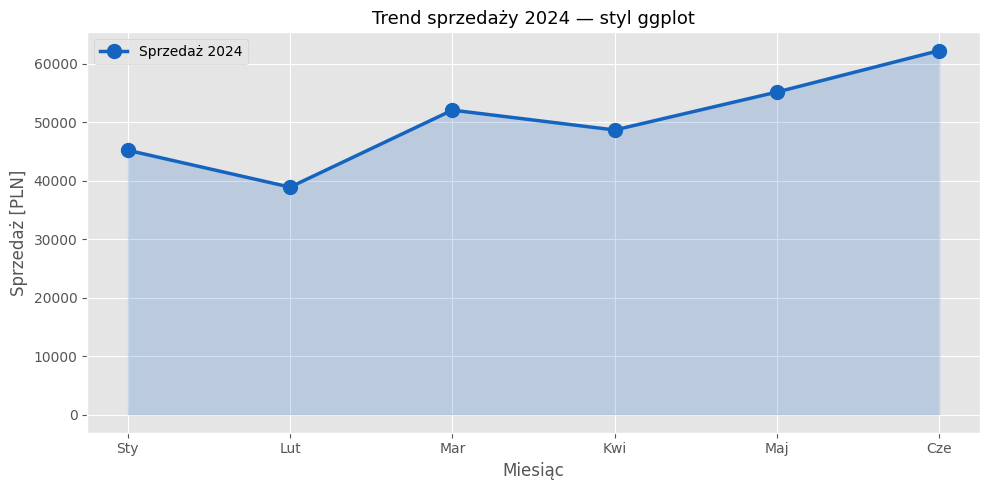

In [11]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = '#1565C0',
        linewidth = 2.5,
        marker = 'o',
        markersize = 10,
        label = 'Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
                alpha = 0.2,                # przezroczystość 0-1; subtelny efekt = 0.1-0.2
                color = '#1565C0')                # ten sam kolor co linia powyżej dla spójności

ax.set_title('Trend sprzedaży 2024 — styl ggplot', fontsize = 13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()

plt.tight_layout()
plt.savefig('trend_styl_ggplot.png', dpi = 100)
plt.show()
plt.close()


- bmh

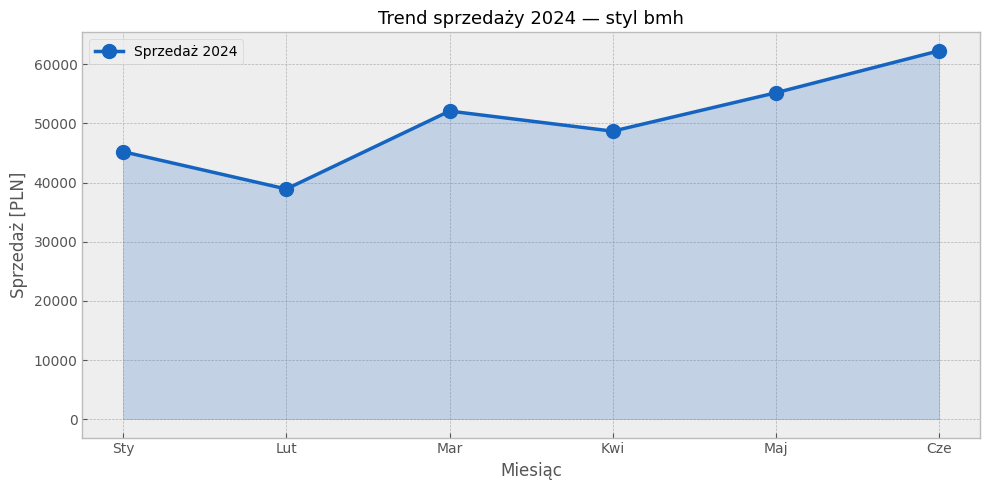

In [12]:
plt.style.use('bmh')

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = '#1565C0',
        linewidth = 2.5,
        marker = 'o',
        markersize = 10,
        label = 'Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
                alpha = 0.2,                # przezroczystość 0-1; subtelny efekt = 0.1-0.2
                color = '#1565C0')                # ten sam kolor co linia powyżej dla spójności

ax.set_title('Trend sprzedaży 2024 — styl bmh', fontsize = 13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()

plt.tight_layout()
plt.savefig('trend_styl_bmh.png', dpi = 100)
plt.show()
plt.close()

- dark_background

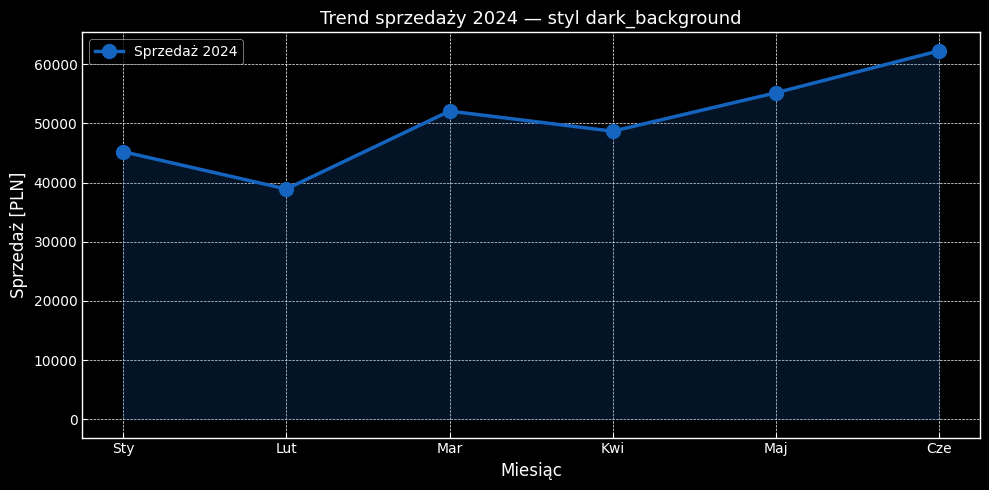

In [13]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = '#1565C0',
        linewidth = 2.5,
        marker = 'o',
        markersize = 10,
        label = 'Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
                alpha = 0.2,                # przezroczystość 0-1; subtelny efekt = 0.1-0.2
                color = '#1565C0')                # ten sam kolor co linia powyżej dla spójności

ax.set_title('Trend sprzedaży 2024 — styl dark_background', fontsize = 13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()

plt.tight_layout()
plt.savefig('trend_styl_dark_background.png', dpi = 100)
plt.show()
plt.close()

- fivethirtyeight

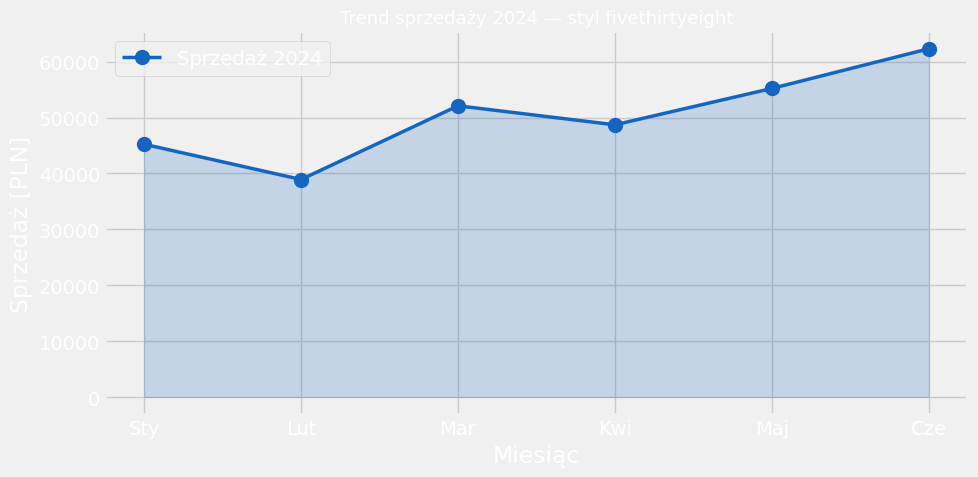

In [14]:
plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(miesiace, sprzedaz_2024,
        color = '#1565C0',
        linewidth = 2.5,
        marker = 'o',
        markersize = 10,
        label = 'Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
                alpha = 0.2,                # przezroczystość 0-1; subtelny efekt = 0.1-0.2
                color = '#1565C0')                # ten sam kolor co linia powyżej dla spójności

ax.set_title('Trend sprzedaży 2024 — styl fivethirtyeight', fontsize = 13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()

plt.tight_layout()
plt.savefig('trend_styl_fivethirtyeight.png', dpi = 100)
plt.show()
plt.close()

## Ćwiczenie 3: Pełna wizualizacja z datasetu tips

Cel: Przeprowadzić samodzielnie analizę wizualną datasetu tips i odpowiedzieć na pytania biznesowe.

### Zadanie 3.1 — Kiedy klienci zostawiają najwyższe napiwki?
Oblicz średni napiwek per dzień tygodnia i narysuj wykres słupkowy.

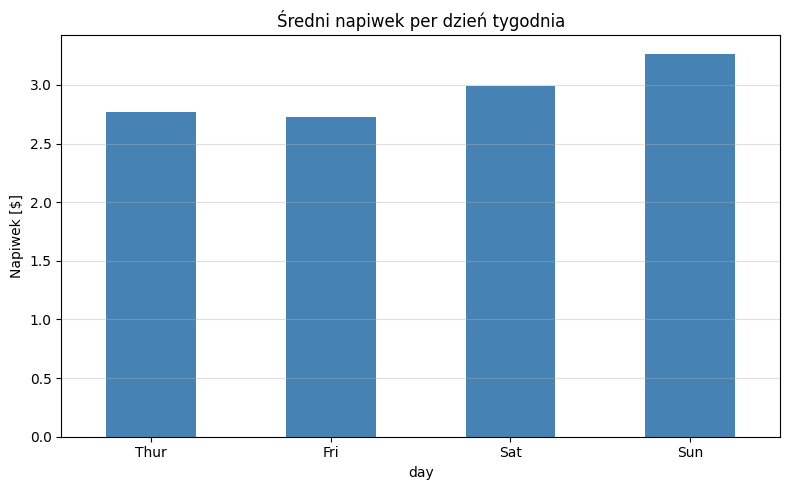

In [6]:
plt.style.use('default')

sredni_napiwek = tips.groupby('day')['tip'].mean().round(2)

ax = sredni_napiwek.plot(
    kind = 'bar',
    figsize = (8, 5),
    color = 'steelblue',
    title = 'Średni napiwek per dzień tygodnia',
    ylabel = 'Napiwek [$]',
    rot = 0
)
ax.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.savefig('napiwek_dzien.png')     
plt.show()
plt.close()

Wniosek: W niedzielę występują najwyższe napiwki.

### Zadanie 3.2 — Czy palacze dają wyższe napiwki?
Narysuj scatter: total_bill vs tip, z kolorowaniem według kolumny smoker (Tak/Nie).

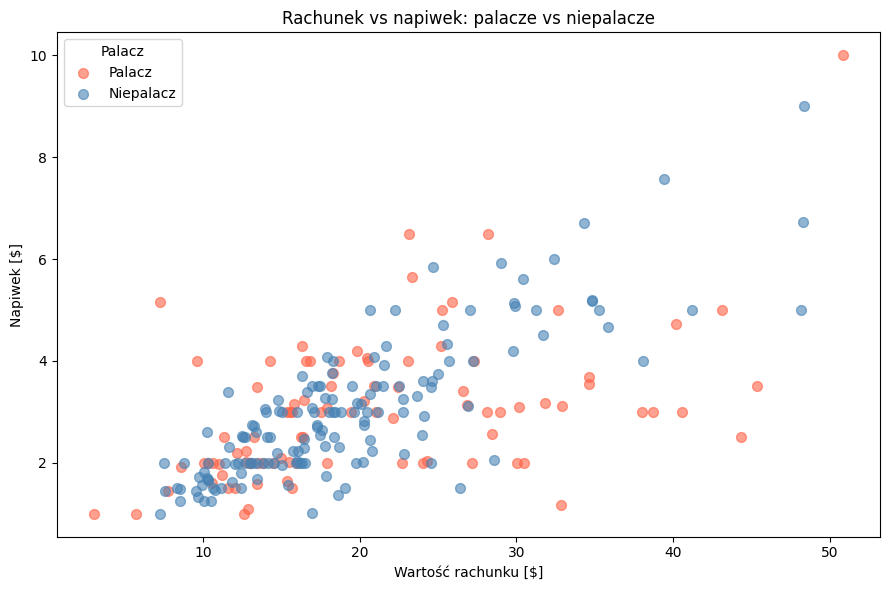

Zapisano: scatter_palacze.png


In [7]:
fig, ax = plt.subplots(figsize = (9, 6))

palacze = tips[tips['smoker'] == 'Yes']
niepalacze = tips[tips['smoker'] == 'No']

ax.scatter(palacze['total_bill'],
           palacze['tip'],
           alpha = 0.6, color = 'tomato', label = 'Palacz', s = 50)

ax.scatter(niepalacze['total_bill'],
           niepalacze['tip'],
           alpha = 0.6, color = 'steelblue', label = 'Niepalacz', s = 50)

ax.set_title('Rachunek vs napiwek: palacze vs niepalacze')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')
ax.legend(title = 'Palacz')

plt.tight_layout()
plt.savefig('scatter_palacze.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: scatter_palacze.png")

Wniosek: Nie widać wyraźnej różnicy. Palenie nie ma bezpośredniego związku z wysokością napiwku.

### Zadanie 3.3 — Rozkład napiwków (histogram + obserwacja)
Narysuj histogram kolumny tip. Dobierz liczbę binów tak, żeby wykres był informatywny (spróbuj bins=10, 20, 30 i wybierz najlepszy).

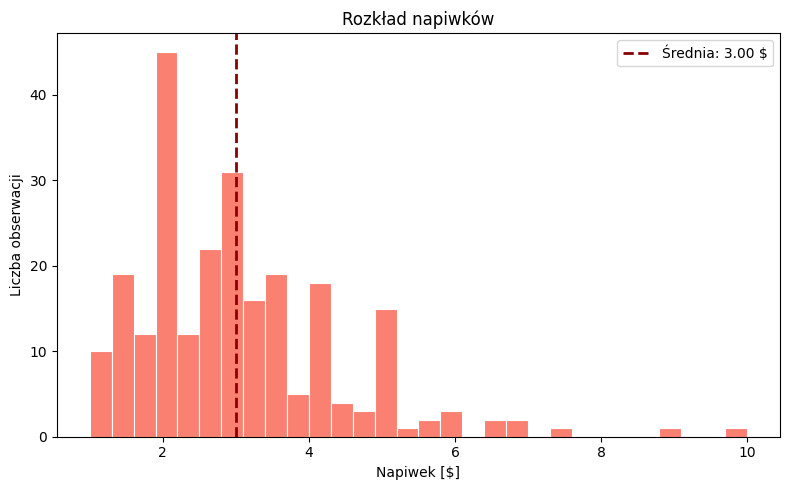

Zapisano: histogram_napiwki.png


In [ ]:
fig, ax = plt.subplots(figsize = (8, 5))

ax.hist(tips['tip'],
        bins = 30,      # spróbuj 10, 20, 30 — który najczytelniej?
        color = 'salmon',
        edgecolor = 'white',
        linewidth = 0.8)

ax.set_title('Rozkład napiwków')
ax.set_xlabel('Napiwek [$]')
ax.set_ylabel('Liczba obserwacji')

# Dodaj pionową linię — średnia
ax.axvline(tips['tip'].mean(),
           color = 'darkred',
           linewidth = 2,
           linestyle = '--',
           label = f"Średnia: {tips['tip'].mean():.2f} $")
ax.legend()

plt.tight_layout()
plt.savefig('histogram_napiwki.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: histogram_napiwki.png")

Wniosek: Średnia kwota napiwku wynosi 3$. Występuje asymetria prawostronna -> częściej zdarzają się napiwki poniżej średniej.

### Zadanie 3.4 — Słupkowy: liczba zamówień per pora dnia
Oblicz liczbę zamówień per time (Lunch/Dinner) i per sex. Narysuj wykres słupkowy grupowany.

sex     Male  Female
time                
Lunch     33      35
Dinner   124      52


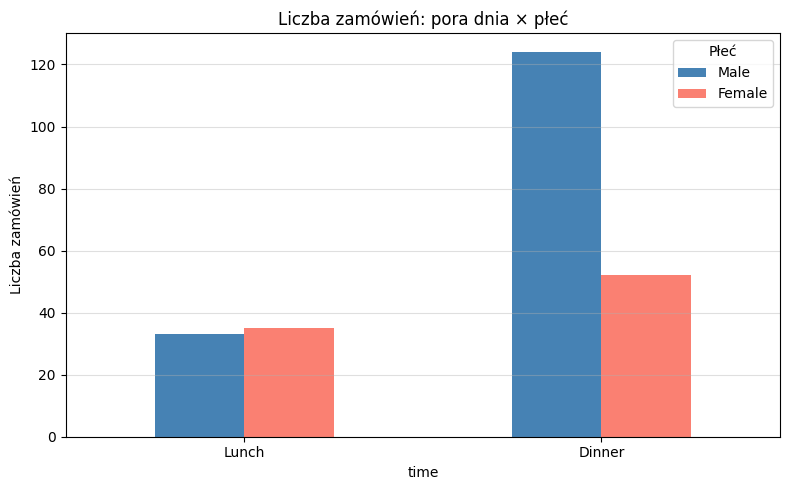

Zapisano: zamowienia_pora.png


In [ ]:
# Zlicz zamówienia per pora dnia i płeć
count_df = tips.groupby(['time', 'sex'], observed=True)['total_bill'].count().unstack()
print(count_df)

# Wykres słupkowy grupowany — pora dnia w wierszach, płeć w kolumnach
ax = count_df.plot(
    kind = 'bar',
    figsize = (8, 5),
    color = ['steelblue', 'salmon'],
    title = 'Liczba zamówień: pora dnia × płeć',
    ylabel = 'Liczba zamówień',
    rot = 0
)
ax.legend(title = 'Płeć')
ax.grid(axis = 'y', alpha = 0.4)

plt.tight_layout()
plt.savefig('zamowienia_pora.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: zamowienia_pora.png")

Wniosek: W porze lunchu liczby są zbliżone. W porze kolacji zncząco dominuje ilość mężczyzn. Może być to spowodowane spotkaniami służbowymi lub takimi, gdzie po prostu mężczyzna płaci za cały stolik.

### Własna obserwacja
W niedzielę występują najwyższe napiwki. Nie jest to bezpośroednio zależne od tego, czy klient jest osobą palącą. Średnia kwota napiwku to 3$, najczęściej występują napiwki poniżej tej kwoty (asymetria prawostronna).
W trakcie lunchu płeć osoby zamawiającej jest praktycznie taka sama, z niewielką przewagą mężczyzn. Wieczorami występuje znacząca przewaga mężczyzn płacących za stolik.

## Ćwiczenie 4: Wiele wykresów (subplots)
Cel: Zbudować dashboard analityczny 2×2, zapisać PNG

### Zadanie 4.1 — Dashboard tips 2×2

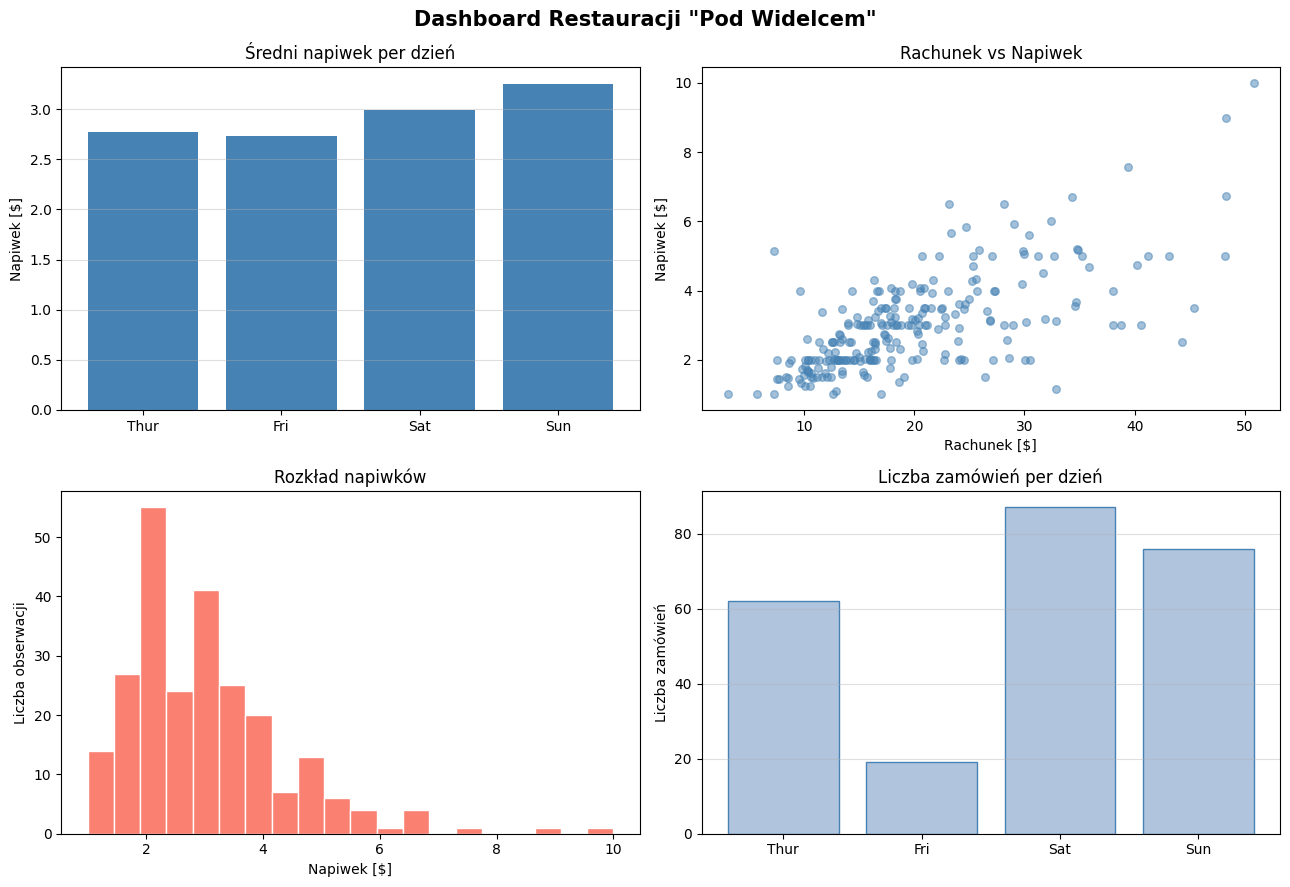

Zapisano: dashboard_tips.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# [0, 0] — Średni napiwek per dzień (słupkowy)
sredni_napiwek_dzien = tips.groupby('day', observed = True)['tip'].mean()
axes[0, 0].bar(sredni_napiwek_dzien.index,
               sredni_napiwek_dzien.values,
               color = 'steelblue')
axes[0, 0].set_title('Średni napiwek per dzień')
axes[0, 0].set_ylabel('Napiwek [$]')
axes[0, 0].grid(axis = 'y', alpha = 0.4)

# [0, 1] — Scatter: rachunek vs napiwek
axes[0, 1].scatter(tips['total_bill'], tips['tip'],
                   alpha = 0.5,
                   color = 'steelblue',
                   s = 30)
axes[0, 1].set_title('Rachunek vs Napiwek') 
axes[0, 1].set_xlabel('Rachunek [$]')
axes[0, 1].set_ylabel('Napiwek [$]')

# [1, 0] — Histogram napiwków
axes[1, 0].hist(tips['tip'],
                bins = 20,
                color = 'salmon',
                edgecolor = 'white')
axes[1, 0].set_title('Rozkład napiwków')
axes[1, 0].set_xlabel('Napiwek [$]')
axes[1, 0].set_ylabel('Liczba obserwacji')

# [1, 1] — Liczba zamówień per dzień (bar)
zamowienia_dzien = tips.groupby('day', observed = True)['total_bill'].count()
axes[1, 1].bar(zamowienia_dzien.index,
               zamowienia_dzien.values,
               color = 'lightsteelblue',
               edgecolor = 'steelblue')
axes[1, 1].set_title('Liczba zamówień per dzień')
axes[1, 1].set_ylabel('Liczba zamówień')
axes[1, 1].grid(axis = 'y', alpha = 0.4)

plt.suptitle('Dashboard Restauracji "Pod Widelcem"',
             fontsize = 15, fontweight = 'bold')
plt.tight_layout()
plt.savefig('dashboard_tips.png', dpi = 100)
plt.show()
plt.close()
print("Zapisano: dashboard_tips.png")